**INTEGRANTES DO GRUPO**

CLEYTON ENRIKE DE OLIVEIRA – RM 560485 - Turma 1TDSQ

MATHEUS HENRIQUE NASCIMENTO DE FREITAS – RM 560442 - Turma 1TDSQ

MATHEUS PINHEIRO ERMACORA MARTIN – RM 557720 - Turma 1TDSZ

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##LENDO O ARQUIVO CSV##

In [15]:
estacoes = pd.read_csv('estacoes.csv', sep=',')

In [16]:
estacoes.head()

,estacaoId,nomeEstacao,quantidade_passageiro,densidade_passageiro,linha_referencia
0,1,Luz,1878089,9.8,7
1,2,Brás,1185328,8.5,7
2,3,Tatuapé,1208779,7.2,12
3,4,Corinthians Itaquera,1089315,8.0,3
4,5,Dom Bosco,470204,5.4,11


In [17]:
estacoes['quantidade_passageiro'].describe()

,quantidade_passageiro
count,1.040000e+02
mean,6.811542e+05
std,5.405293e+05
min,2.783400e+04
25%,2.985652e+05
50%,5.018535e+05
75%,9.425000e+05
max,3.413957e+06


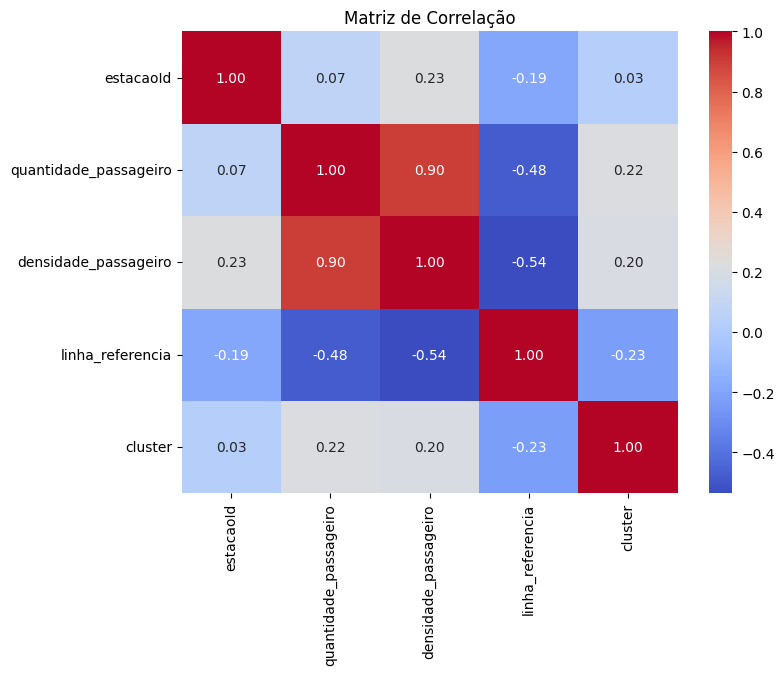

In [94]:
correlacoes = estacoes.select_dtypes(include=np.number).corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlacoes, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação')
plt.show()

In [18]:
estacoes['quantidade_passageiro'].value_counts()

,count
quantidade_passageiro,
1250000,3
870000,2
980000,2
380000,2
370000,2
...,...
970000,1
450000,1
400000,1


**Gráfico BoxPlot**

<Axes: ylabel='quantidade_passageiro'>

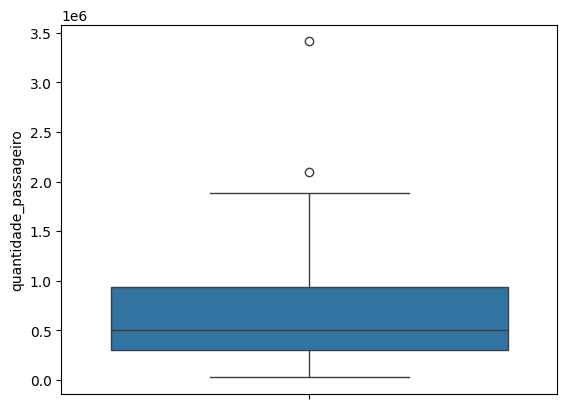

In [91]:
sns.boxplot(estacoes['quantidade_passageiro'])

**Gráfico Scatter**

In [23]:
estacoes['quantidade_passageiro'].unique()

array([1878089, 1185328, 1208779, 1089315,  470204,  438996, 1887116,
        370919,  666634,  325318,  161811,  975114,  195425,  195533,
        297006,  375526,  321248, 1217396, 3413957,  202378,  748135,
        223779,  423517,   99284,  428617,  254131,  548289,  299085,
        503707,  219768,  775605,   50047,  108008,   60991,  325345,
        244071,  286674, 1729374,  715263,  206467,  203862, 1349757,
        170006, 1174678,  192580,  384373,  227615,  655199,  170414,
        138813,  215184,  444842,  403217,  763800,  472869,  235139,
        466795,  169598,   45972,   27834,  431242,  870000,  540000,
       1350000,  860000, 2100000, 1250000, 1400000,  980000, 1700000,
        380000,  950000,  730000,  800000, 1200000,  740000,  930000,
       1500000,  520000,  720000,  670000,  820000,  640000,  530000,
        500000, 1600000,  940000,  370000,  600000,  780000,  910000,
        470000,  970000,  450000,  400000,  410000,  340000])

In [24]:
estacoes['quantidade_passageiro'].value_counts()

,count
quantidade_passageiro,
1250000,3
870000,2
980000,2
380000,2
370000,2
...,...
970000,1
450000,1
400000,1


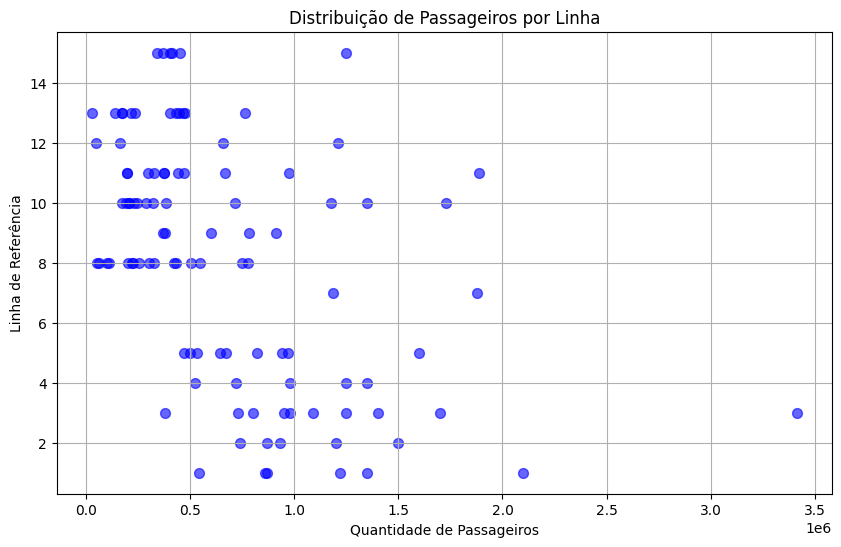

In [92]:
plt.figure(figsize=(10, 6))
plt.scatter(estacoes['quantidade_passageiro'], estacoes['linha_referencia'], alpha=0.6, s=50, c='blue')
plt.xlabel('Quantidade de Passageiros')
plt.ylabel('Linha de Referência')
plt.title('Distribuição de Passageiros por Linha')
plt.grid(True)
plt.show()

##MODELO LDA##

In [89]:
from sklearn.model_selection import train_test_split

In [31]:
estacoes['nomeEstacao']

x = estacoes.drop(columns = ['nomeEstacao'])
y = estacoes['linha_referencia']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 42)


In [32]:
y_train.head()

,linha_referencia
103,15
78,2
28,8
79,4
5,11


In [33]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis()
lda.fit(x_train, y_train)
y_pred = lda.predict(x_test)

In [34]:
y_predicoes = lda.predict(x_test)

**MATRIZ CONFUSÃO**

In [35]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, classification_report

In [39]:
estacoes['densidade_passageiro'].value_counts()

,count
densidade_passageiro,
7.5,5
4.8,4
4.2,3
5.4,3
6.0,3
...,...
6.8,1
6.6,1
9.4,1


In [41]:
unique_desindade = y.unique()

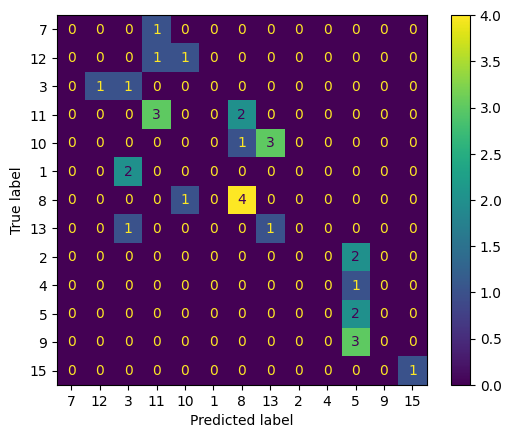

In [43]:
matriz_confusao = confusion_matrix(
    y_true=y_test,
    y_pred=y_predicoes,
    labels=unique_desindade
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusao,
    display_labels=unique_desindade
)
disp.plot(values_format='d')
plt.show()

**Acurácia**

In [44]:
accuracy_score(y_test, y_predicoes)

0.375

In [46]:
lda.coef_[0] #c1, c2
lda.coef_[0,1]
lda.intercept_/lda.coef_[0,1]
lda.coef_[0,0]/lda.coef_[0,1]
x1 = np.arange(0,10)
x2 = -2.635*x1 + 18.51
x_train

,estacaoId,quantidade_passageiro,densidade_passageiro,linha_referencia
103,104,1250000,9.0,15
78,79,1500000,9.2,2
28,29,503707,6.3,8
79,80,1350000,8.8,4
5,6,438996,4.8,11
...,...,...,...,...
71,72,950000,7.7,3
14,15,297006,4.1,11
92,93,380000,5.2,9
51,52,444842,5.9,13


**Gráfico COEF**

Index(['estacaoId', 'nomeEstacao', 'quantidade_passageiro',
       'densidade_passageiro', 'linha_referencia'],
      dtype='object')


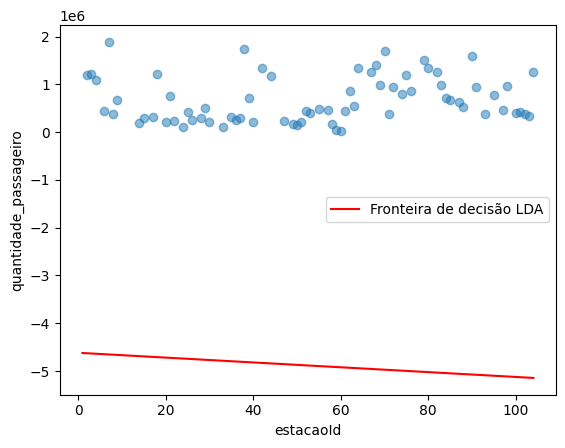

In [54]:
coefficients = lda.coef_[0]

c1, c2 = coefficients[:2]

b = lda.intercept_[0]

x1 = np.linspace(estacoes['estacaoId'].min(), estacoes['estacaoId'].max(), 100)

print(estacoes.columns)

x2 = -(c1 / c2) * x1 - b / c2

plt.plot(x1, x2, color='red', label='Fronteira de decisão LDA')


plt.scatter(x_train['estacaoId'], x_train['quantidade_passageiro'], alpha=0.5)

plt.xlabel('estacaoId')
plt.ylabel('quantidade_passageiro')
plt.legend()
plt.show()

**Gráfico de Regressão Linear**

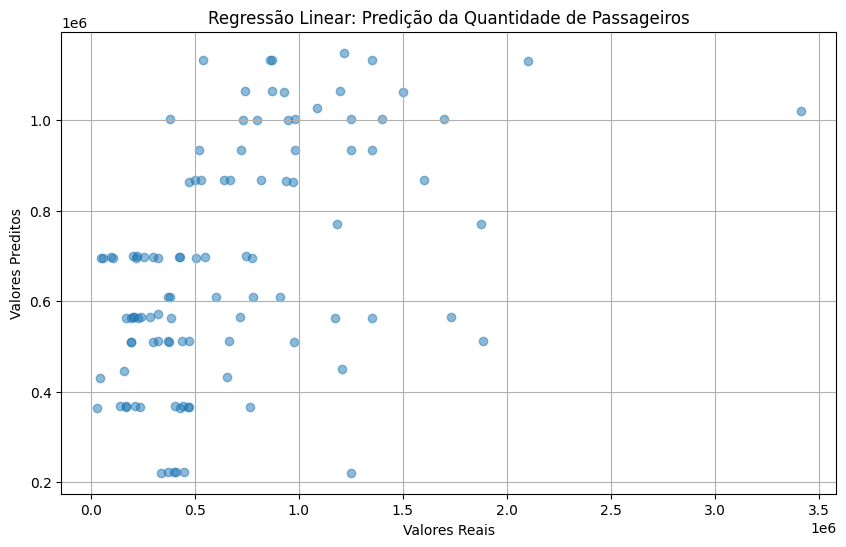

In [98]:
from sklearn.linear_model import LinearRegression

X = estacoes[['estacaoId', 'linha_referencia']]
y = estacoes['quantidade_passageiro']

modelo = LinearRegression()
modelo.fit(X, y)

y_pred = modelo.predict(X)

plt.figure(figsize=(10, 6))
plt.scatter(y, y_pred, alpha=0.5)
plt.xlabel('Valores Reais')
plt.ylabel('Valores Preditos')
plt.title('Regressão Linear: Predição da Quantidade de Passageiros')
plt.grid(True)
plt.show()

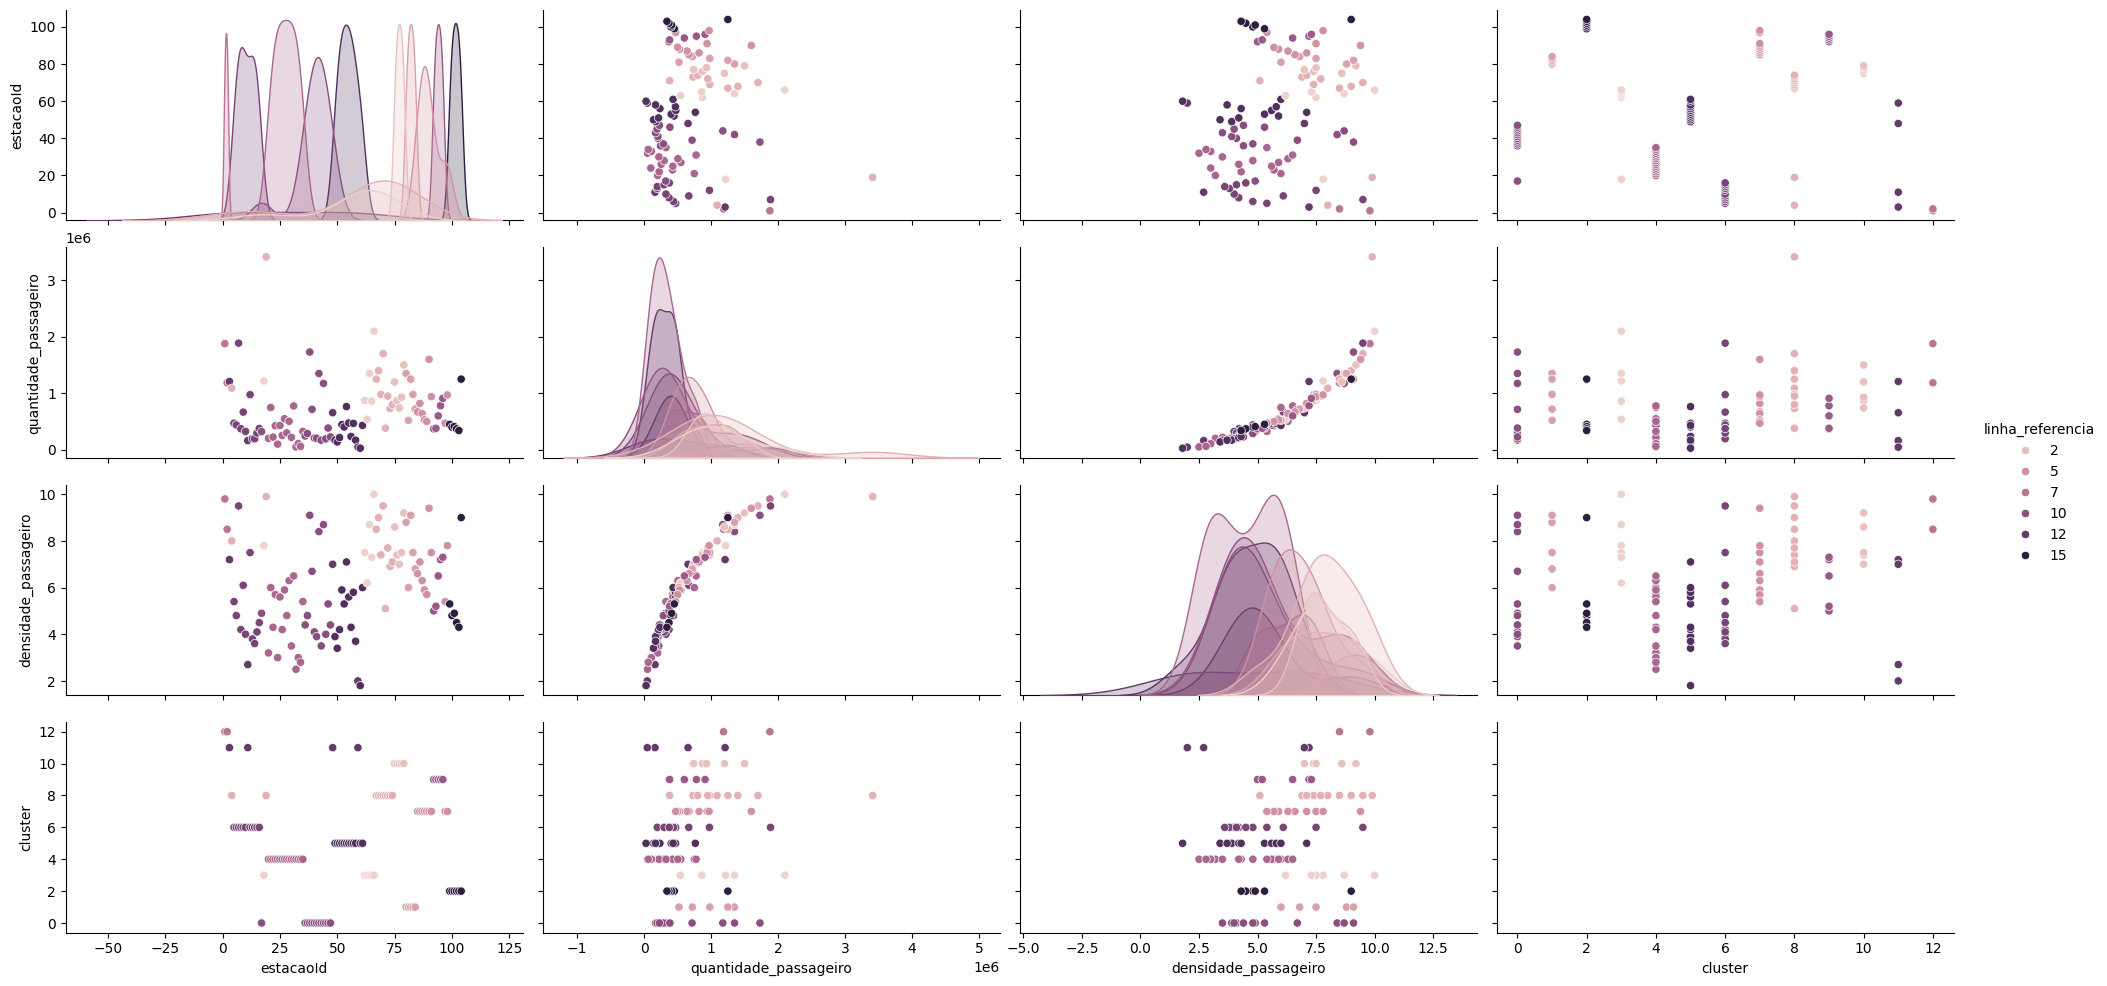

In [105]:
sns.pairplot(estacoes, hue='linha_referencia', aspect=2)

**Gráfico de Histograma**

<ipython-input-104-4ce692f691b2>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='linha_referencia', y='quantidade_passageiro', data=passageiros_por_linha, order=passageiros_por_linha['linha_referencia'], palette='GnBu_d')


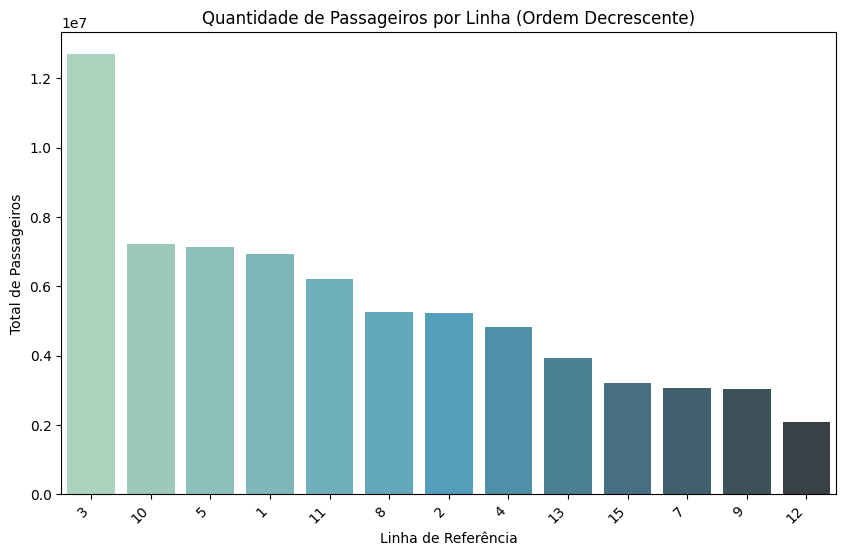

In [104]:
passageiros_por_linha = estacoes.groupby('linha_referencia')['quantidade_passageiro'].sum().reset_index()
passageiros_por_linha = passageiros_por_linha.sort_values(by='quantidade_passageiro', ascending=False)  # <-- Ordenação DESC

plt.figure(figsize=(10, 6))
sns.barplot(x='linha_referencia', y='quantidade_passageiro', data=passageiros_por_linha, order=passageiros_por_linha['linha_referencia'], palette='GnBu_d')

plt.title('Quantidade de Passageiros por Linha (Ordem Decrescente)')
plt.xlabel('Linha de Referência')
plt.ylabel('Total de Passageiros')
plt.xticks(rotation=45, ha='right')

plt.show()

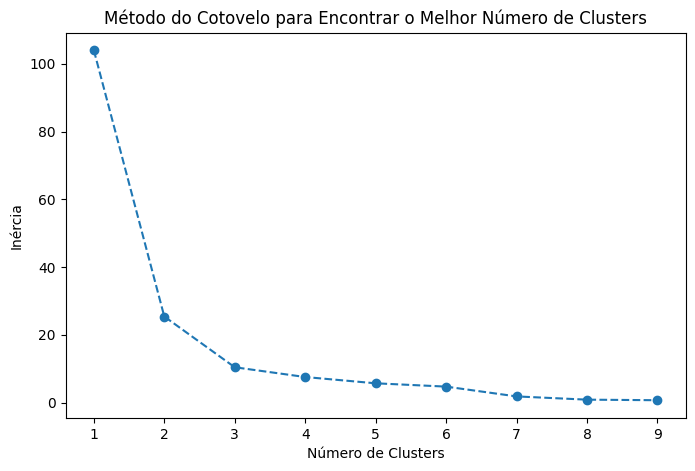

In [106]:
from sklearn.cluster import KMeans

inertia = []
K_range = range(1, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.xlabel('Número de Clusters')
plt.ylabel('Inércia')
plt.title('Método do Cotovelo para Encontrar o Melhor Número de Clusters')
plt.show()